## Week 1: Data Collection
In this step, we collect historical market data for selected financial assets using the Yahoo Finance API.  
The dataset contains daily closing prices which will be used for portfolio analysis.


In [1]:
!pip install yfinance pandas numpy matplotlib


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 426.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.6 MB 426.7 kB/s eta 0:00:03
   ------------ ---------------

### Step 1: Import Required Libraries
In this step, we import the Python libraries required for financial data analysis and visualization.

- **yfinance** is used to download financial market data
- **pandas** is used for data manipulation and analysis
- **numpy** is used for numerical calculations
- **matplotlib** is used for visualization

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries imported successfully 🚀")


All libraries imported successfully 🚀


### Step 2: Download Historical Stock Data
In this step, we download historical price data for selected assets from Yahoo Finance.  
The dataset includes assets from different sectors to create a diversified portfolio.

In [5]:
raw_data = yf.download(assets, start="2019-01-01", end="2024-12-31")

print(raw_data.columns)


[*********************100%***********************]  6 of 6 completed

MultiIndex([( 'Close',    'AAPL'),
            ( 'Close', 'BTC-USD'),
            ( 'Close',     'JPM'),
            ( 'Close',     'SPY'),
            ( 'Close',    'TSLA'),
            ( 'Close',     'XOM'),
            (  'High',    'AAPL'),
            (  'High', 'BTC-USD'),
            (  'High',     'JPM'),
            (  'High',     'SPY'),
            (  'High',    'TSLA'),
            (  'High',     'XOM'),
            (   'Low',    'AAPL'),
            (   'Low', 'BTC-USD'),
            (   'Low',     'JPM'),
            (   'Low',     'SPY'),
            (   'Low',    'TSLA'),
            (   'Low',     'XOM'),
            (  'Open',    'AAPL'),
            (  'Open', 'BTC-USD'),
            (  'Open',     'JPM'),
            (  'Open',     'SPY'),
            (  'Open',    'TSLA'),
            (  'Open',     'XOM'),
            ('Volume',    'AAPL'),
            ('Volume', 'BTC-USD'),
            ('Volume',     'JPM'),
            ('Volume',     'SPY'),
            ('Volume

In [6]:
# Download data
raw_data = yf.download(assets, start="2019-01-01", end="2024-12-31")

# Extract Close prices properly
data = raw_data['Close']

# Show first 5 rows
data.head()


[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,BTC-USD,JPM,SPY,TSLA,XOM
Date,,,,,,
2019-01-01,NaN,3843.520020,NaN,NaN,NaN,NaN
2019-01-02,37.503731,3943.409424,81.250198,224.995346,20.674667,50.001850
2019-01-03,33.768082,3836.741211,80.095505,219.626297,20.024000,49.234131
2019-01-04,35.209614,3857.717529,83.048256,226.982849,21.179333,51.049370
2019-01-05,NaN,3845.194580,NaN,NaN,NaN,NaN


In [7]:
# Remove rows where all values are NaN
data = data.dropna(how='all')

# Forward fill missing values (important for crypto alignment)
data = data.fillna(method='ffill')

# Check again
data.head()


C:\Users\jadha\AppData\Local\Temp\ipykernel_24256\2107215535.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


Ticker,AAPL,BTC-USD,JPM,SPY,TSLA,XOM
Date,,,,,,
2019-01-01,NaN,3843.520020,NaN,NaN,NaN,NaN
2019-01-02,37.503731,3943.409424,81.250198,224.995346,20.674667,50.001850
2019-01-03,33.768082,3836.741211,80.095505,219.626297,20.024000,49.234131
2019-01-04,35.209614,3857.717529,83.048256,226.982849,21.179333,51.049370
2019-01-05,35.209614,3845.194580,83.048256,226.982849,21.179333,51.049370


In [8]:
data.isnull().sum()


Ticker
AAPL       1
BTC-USD    0
JPM        1
SPY        1
TSLA       1
XOM        1
dtype: int64

## Week 2: Data Processing
In this phase, we process the collected data and prepare it for portfolio analysis.  
This includes calculating daily returns and constructing a weighted portfolio.

### Step 3: Calculate Daily Returns
Daily returns represent the percentage change in asset prices from one day to the next.

This metric is essential for evaluating portfolio performance and calculating risk metrics.

In [9]:
# Calculate daily log returns
log_returns = np.log(data / data.shift(1))

log_returns = log_returns.dropna()

log_returns.head()


Ticker,AAPL,BTC-USD,JPM,SPY,TSLA,XOM
Date,,,,,,
2019-01-03,-0.104924,-0.027422,-0.014314,-0.024152,-0.031978,-0.015473
2019-01-04,0.041803,0.005452,0.036202,0.032947,0.056094,0.036206
2019-01-05,0.000000,-0.003251,0.000000,0.000000,0.000000,0.000000
2019-01-06,0.000000,0.058447,0.000000,0.000000,0.000000,0.000000
2019-01-07,-0.002228,-0.012685,0.000695,0.007854,0.052935,0.005187


In [10]:
# Equal weights portfolio
weights = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

weights


array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

### Step 4: Portfolio Construction using Asset Weights
In this step, we assign weights to each asset to create a diversified investment portfolio.

The weighted returns of all assets are combined to calculate the overall portfolio return.

In [11]:
# Portfolio daily return
portfolio_returns = log_returns.dot(weights)

portfolio_returns.head()


Date
2019-01-03   -0.036377
2019-01-04    0.034784
2019-01-05   -0.000542
2019-01-06    0.009741
2019-01-07    0.008626
Freq: D, dtype: float64

In [12]:
# Covariance matrix
cov_matrix = log_returns.cov()

# Annualized portfolio volatility
portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix * 252, weights))
)

print("Annual Portfolio Volatility:", portfolio_volatility)


Annual Portfolio Volatility: 0.22732753720726007


In [13]:
# Annualized mean return
portfolio_return = np.sum(log_returns.mean() * weights) * 252

print("Annual Expected Return:", portfolio_return)


Annual Expected Return: 0.20669593548918913


### Value at Risk (VaR) Calculation
Value at Risk estimates the maximum expected loss of the portfolio within a specified confidence level.

In this project, we calculate VaR at the 95% confidence level.

In [14]:
# 95% Value at Risk
confidence_level = 0.05

VaR = np.percentile(portfolio_returns, 100 * confidence_level)

print("Daily 95% VaR:", VaR)


Daily 95% VaR: -0.020845962186718192


# Monte Carlo parameters

In [15]:
# Monte Carlo parameters
num_simulations = 10000
num_days = 252  # 1 year
initial_portfolio_value = 100000  # assume 1 lakh investment

# Mean and standard deviation of portfolio returns
mean_return = portfolio_returns.mean()
std_dev = portfolio_returns.std()


# Simulate random daily returns

In [16]:
# Simulate random daily returns
simulated_returns = np.random.normal(
    mean_return,
    std_dev,
    (num_days, num_simulations)
)

# Convert returns to price paths
simulated_portfolio = initial_portfolio_value * np.exp(
    np.cumsum(simulated_returns, axis=0)
)

simulated_portfolio.shape


(252, 10000)

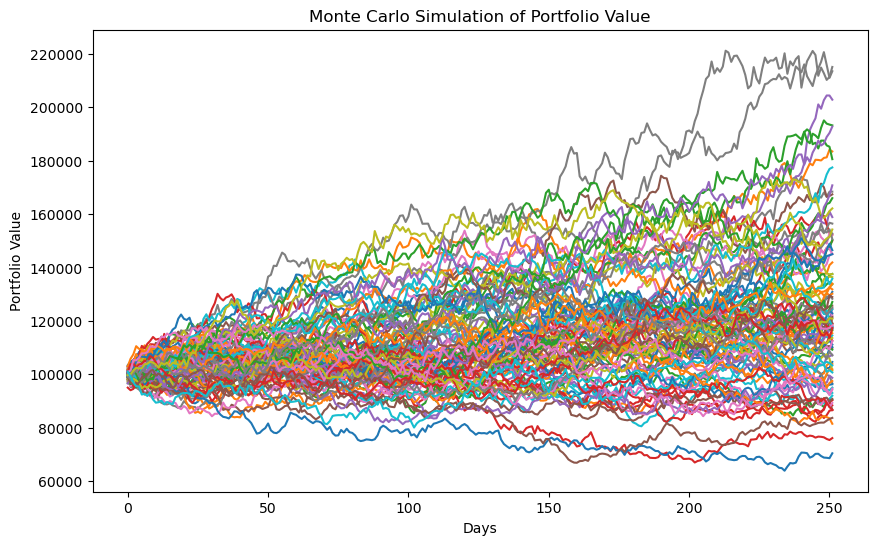

In [17]:
plt.figure(figsize=(10,6))
plt.plot(simulated_portfolio[:, :100])  # plot first 100 paths
plt.title("Monte Carlo Simulation of Portfolio Value")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.show()


In [18]:
# Final portfolio values after 1 year
final_values = simulated_portfolio[-1]

# 95% VaR
future_VaR = np.percentile(final_values, 5)

print("1-Year 95% Monte Carlo VaR:", initial_portfolio_value - future_VaR)


1-Year 95% Monte Carlo VaR: 15444.642611813528


In [19]:
risk_free_rate = 0.05  # 5% assumed

sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

print("Sharpe Ratio:", sharpe_ratio)


Sharpe Ratio: 0.6892958829986604


In [21]:
cumulative_returns = (1 + portfolio_returns).cumprod()
running_max = cumulative_returns.cummax()

drawdown = (cumulative_returns - running_max) / running_max

max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)


Maximum Drawdown: -0.44457153998496773


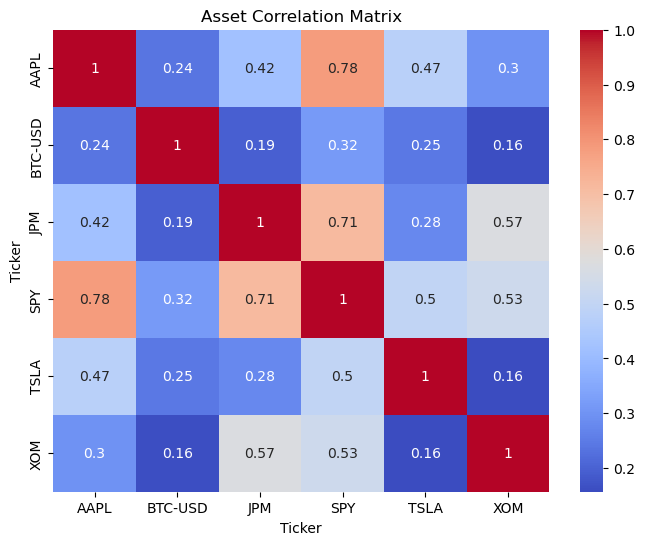

In [22]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(log_returns.corr(), annot=True, cmap="coolwarm")
plt.title("Asset Correlation Matrix")
plt.show()


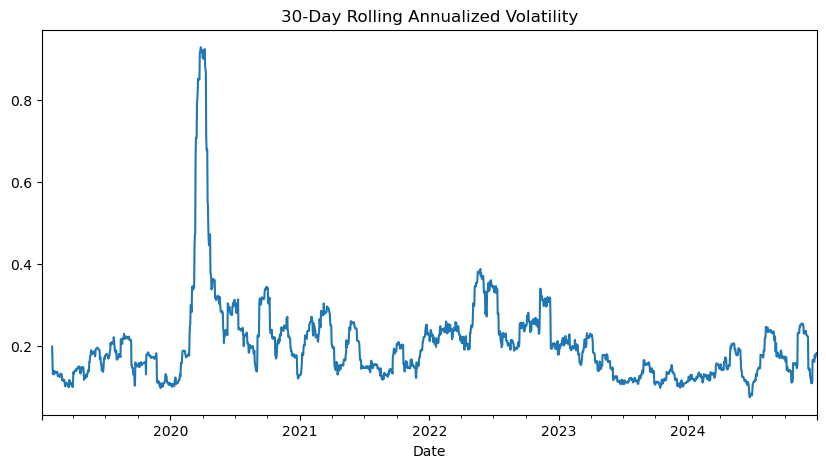

In [23]:
rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(10,5))
rolling_volatility.plot()
plt.title("30-Day Rolling Annualized Volatility")
plt.show()


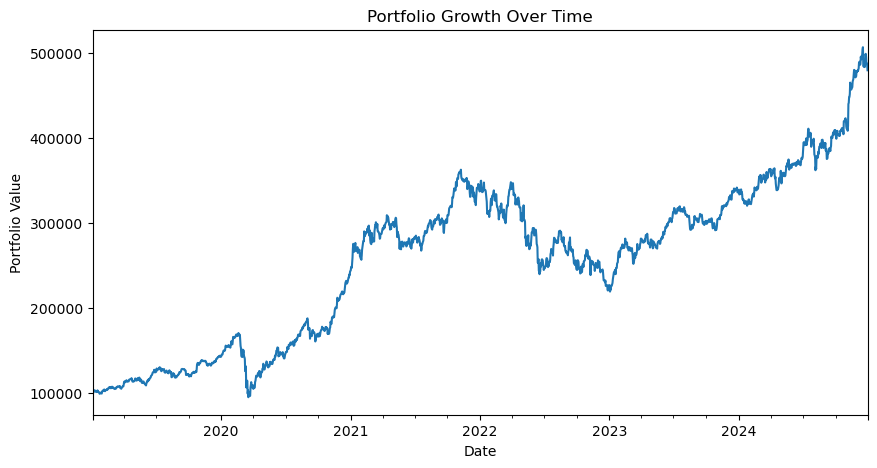

In [24]:
portfolio_growth = 100000 * (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,5))
portfolio_growth.plot()
plt.title("Portfolio Growth Over Time")
plt.ylabel("Portfolio Value")
plt.show()



In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Daily 95% VaR",
        "1-Year Monte Carlo VaR"
    ],
    "Value": [
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        max_drawdown,
        VaR,
        initial_portfolio_value - future_VaR
    ]
})

summary


,Metric,Value
0,Annual Return,0.206696
1,Annual Volatility,0.227328
2,Sharpe Ratio,0.689296
3,Maximum Drawdown,-0.444572
4,Daily 95% VaR,-0.020846
5,1-Year Monte Carlo VaR,15444.642612


## Week 4: Data Export for Visualization
In the final step, we export the processed portfolio metrics to a CSV file.

This dataset will be used to create interactive visualizations and dashboards in Tableau.

In [26]:
summary.to_csv("alphapulse_summary_metrics.csv", index=False)


In [27]:
portfolio_returns.to_csv("portfolio_daily_returns.csv")
rolling_volatility.to_csv("rolling_volatility.csv")
portfolio_growth.to_csv("portfolio_growth.csv")


In [28]:
portfolio_returns.to_csv("portfolio_daily_returns.csv")
rolling_volatility.to_csv("rolling_volatility.csv")
portfolio_growth.to_csv("portfolio_growth.csv")
summary.to_csv("alphapulse_summary_metrics.csv", index=False)


In [29]:
# Conditional VaR (Expected Shortfall)
cvar = portfolio_returns[portfolio_returns <= VaR].mean()

print("Conditional VaR (CVaR):", cvar)

Conditional VaR (CVaR): -0.03513842811238938


In [30]:
# Marginal Risk Contribution
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))

marginal_contribution = np.dot(cov_matrix * 252, weights)

risk_contribution = weights * marginal_contribution / portfolio_volatility

risk_contribution_df = pd.DataFrame({
    "Asset": log_returns.columns,
    "Risk Contribution": risk_contribution
})

risk_contribution_df

,Asset,Risk Contribution
0,AAPL,0.029854
1,BTC-USD,0.058549
2,JPM,0.027462
3,SPY,0.022753
4,TSLA,0.064232
5,XOM,0.024478


In [31]:
risk_contribution_df.to_csv("risk_contribution.csv", index=False)
log_returns.corr().to_csv("correlation_matrix.csv")

In [34]:
%who

VaR	 assets	 confidence_level	 cov_matrix	 cumulative_returns	 cvar	 data	 dataframe_columns	 dataframe_hash	 
drawdown	 dtypes_str	 final_values	 future_VaR	 get_dataframes	 getpass	 hashlib	 import_pandas_safely	 initial_portfolio_value	 
is_data_frame	 json	 log_returns	 marginal_contribution	 max_drawdown	 mean_return	 np	 num_days	 num_simulations	 
pd	 plt	 portfolio_growth	 portfolio_return	 portfolio_returns	 portfolio_variance	 portfolio_volatility	 raw_data	 risk_contribution	 
risk_contribution_df	 risk_free_rate	 rolling_volatility	 running_max	 sharpe_ratio	 simulated_portfolio	 simulated_returns	 sns	 std_dev	 
summary	 weights	 yf	 


In [35]:
final_df = log_returns.copy()

final_df["Portfolio_Return"] = portfolio_returns
final_df["Portfolio_Value"] = portfolio_growth

final_df.head()

Ticker,AAPL,BTC-USD,JPM,SPY,TSLA,XOM,Portfolio_Return,Portfolio_Value
Date,,,,,,,,
2019-01-03,-0.104924,-0.027422,-0.014314,-0.024152,-0.031978,-0.015473,-0.036377,96362.283276
2019-01-04,0.041803,0.005452,0.036202,0.032947,0.056094,0.036206,0.034784,99714.164255
2019-01-05,0.000000,-0.003251,0.000000,0.000000,0.000000,0.000000,-0.000542,99660.127700
2019-01-06,0.000000,0.058447,0.000000,0.000000,0.000000,0.000000,0.009741,100630.935093
2019-01-07,-0.002228,-0.012685,0.000695,0.007854,0.052935,0.005187,0.008626,101499.011852


In [36]:
final_df.to_csv("portfolio_final.csv")

In [37]:
final_df.shape

(2189, 8)

In [2]:
import pandas as pd
import numpy as np

In [3]:
%who

dataframe_columns	 dataframe_hash	 dtypes_str	 get_dataframes	 getpass	 hashlib	 import_pandas_safely	 is_data_frame	 json	 
np	 pd	 


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "BTC-USD", "JPM", "SPY", "TSLA", "XOM"]

data = yf.download(tickers, start="2019-01-01", end="2024-01-01")

# Extract Adjusted Close properly
if isinstance(data.columns, pd.MultiIndex):
    data = data["Close"]   # Use Close (already adjusted in new versions)
else:
    data = data

data = data.ffill()

data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,BTC-USD,JPM,SPY,TSLA,XOM
Date,,,,,,
2019-01-01,NaN,3843.520020,NaN,NaN,NaN,NaN
2019-01-02,37.503731,3943.409424,81.250214,224.995270,20.674667,50.001835
2019-01-03,33.768074,3836.741211,80.095497,219.626297,20.024000,49.234127
2019-01-04,35.209618,3857.717529,83.048264,226.982880,21.179333,51.049366
2019-01-05,35.209618,3845.194580,83.048264,226.982880,21.179333,51.049366


In [6]:
returns = data.pct_change().dropna()

In [7]:
weights = np.array([0.15, 0.20, 0.15, 0.20, 0.15, 0.15])

In [8]:
portfolio_returns = returns.dot(weights)

In [9]:
initial_investment = 100000
portfolio_growth = (1 + portfolio_returns).cumprod() * initial_investment

In [10]:
rolling_volatility = portfolio_returns.rolling(window=21).std() * np.sqrt(252)

In [11]:
running_max = portfolio_growth.cummax()
drawdown = (portfolio_growth - running_max) / running_max

In [12]:
final_df = pd.DataFrame({
    "Date": portfolio_returns.index,
    "Portfolio Value": portfolio_growth,
    "Daily Return": portfolio_returns,
    "Rolling Volatility": rolling_volatility,
    "Drawdown": drawdown
})

final_df.to_csv("portfolio_final.csv", index=False)

### Export Final Dataset
The final dataset contains key portfolio metrics including portfolio value, daily returns, rolling volatility, and drawdown.

This dataset is exported to a CSV file for further visualization.

In [13]:
final_df = pd.DataFrame({
    "Date": portfolio_returns.index,
    "Portfolio Value": portfolio_growth,
    "Daily Return": portfolio_returns,
    "Rolling Volatility": rolling_volatility,
    "Drawdown": drawdown
})

final_df.to_csv("portfolio_final.csv", index=False)